## 1. Import Library & Setup

In [172]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import os
import pickle
warnings.filterwarnings('ignore')

# NLP & Text
import re
import string
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, GlobalMaxPooling1D, Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, roc_auc_score,
                              roc_curve, mean_absolute_error, mean_squared_error)
from sklearn.preprocessing import MinMaxScaler

# Visualisasi
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

np.random.seed(42)
tf.random.set_seed(42)
print('Libraries loaded')
print(f'   TensorFlow: {tf.__version__}')


Libraries loaded
   TensorFlow: 2.21.0


## 2. Load Dataset

In [142]:
df       = pd.read_csv('data/data.csv',           encoding='latin1')
df_abuse = pd.read_csv('data/abusive.csv',        encoding='utf-8')
df_kamus = pd.read_csv('data/new_kamusalay.csv',  encoding='latin1', header=0)
df_kamus.columns = ['alay', 'normal']

print(f'Main dataset    : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Abusive lexicon : {df_abuse.shape[0]:,} kata')
print(f'Kamus alay      : {df_kamus.shape[0]:,} entri')
print()
print('Kolom dataset utama:')
print(df.columns.tolist())
df.head(3)


Main dataset    : 13,169 baris × 13 kolom
Abusive lexicon : 125 kata
Kamus alay      : 15,166 entri

Kolom dataset utama:
['Tweet', 'HS', 'Abusive', 'HS_Individual', 'HS_Group', 'HS_Religion', 'HS_Race', 'HS_Physical', 'HS_Gender', 'HS_Other', 'HS_Weak', 'HS_Moderate', 'HS_Strong']


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0


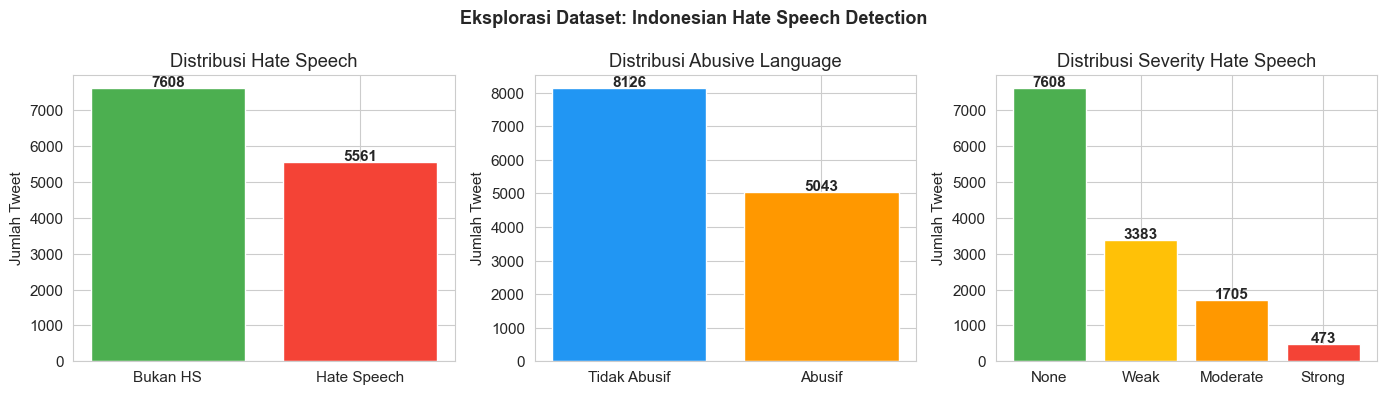

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

label_cols = {
    'HS (Hate Speech)': 'HS',
    'Abusive': 'Abusive',
    'Severity (HS)': None
}

# Plot 1: HS
hs_counts = df['HS'].value_counts()
axes[0].bar(['Bukan HS', 'Hate Speech'], hs_counts.values, color=['#4CAF50','#F44336'])
axes[0].set_title('Distribusi Hate Speech')
axes[0].set_ylabel('Jumlah Tweet')
for i, v in enumerate(hs_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 2: Abusive
ab_counts = df['Abusive'].value_counts()
axes[1].bar(['Tidak Abusif', 'Abusif'], ab_counts.values, color=['#2196F3','#FF9800'])
axes[1].set_title('Distribusi Abusive Language')
axes[1].set_ylabel('Jumlah Tweet')
for i, v in enumerate(ab_counts.values):
    axes[1].text(i, v+50, str(v), ha='center', fontweight='bold')

# Plot 3: Severity
sev_labels = ['None', 'Weak', 'Moderate', 'Strong']
sev_counts = [
    len(df[df['HS']==0]),
    len(df[(df['HS_Weak']==1)&(df['HS_Moderate']==0)&(df['HS_Strong']==0)]),
    len(df[df['HS_Moderate']==1]),
    len(df[df['HS_Strong']==1])
]
colors = ['#4CAF50','#FFC107','#FF9800','#F44336']
axes[2].bar(sev_labels, sev_counts, color=colors)
axes[2].set_title('Distribusi Severity Hate Speech')
axes[2].set_ylabel('Jumlah Tweet')
for i, v in enumerate(sev_counts):
    axes[2].text(i, v+50, str(v), ha='center', fontweight='bold')

plt.suptitle('Eksplorasi Dataset: Indonesian Hate Speech Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/dist_label.png', bbox_inches='tight')
plt.show()


## 3. Preprocessing Teks

In [144]:
alay_dict = dict(zip(df_kamus['alay'].str.lower(), df_kamus['normal'].str.lower()))
abusive_set = set(df_abuse['ABUSIVE'].str.lower().str.strip())

print(f'Kamus alay    : {len(alay_dict):,} entri')
print(f'Lexicon abusif: {len(abusive_set):,} kata')

def normalize_alay(text):
    words = text.split()
    return ' '.join(alay_dict.get(w, w) for w in words)

def preprocess_text(text):
    """Preprocessing pipeline:
       lowercase → remove USER/RT/URL → remove punctuation
       → normalize alay → strip extra spaces"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'\buser\b|\brt\b|\burl\b', '', text)  # token khusus
    text = re.sub(r'http\S+|www\S+', '', text)             # URL
    text = re.sub(r'[^a-z0-9\s]', ' ', text)               # punctuation
    text = normalize_alay(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_tweet'] = df['Tweet'].apply(preprocess_text)
print()
print('Contoh preprocessing:')
for i in range(3):
    print(f'  Asli  : {df["Tweet"].iloc[i][:80]}')
    print(f'  Bersih: {df["clean_tweet"].iloc[i][:80]}')
    print()


Kamus alay    : 15,166 entri
Lexicon abusif: 125 kata

Contoh preprocessing:
  Asli  : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati
  Bersih: di saat semua cowok berusaha melacak perhatian gue kamu lantas remehkan perhatia

  Asli  : RT USER: USER siapa yang telat ngasih tau elu?edan sarap gue bergaul dengan ciga
  Bersih: siapa yang telat memberi tau kamu edan sarap gue bergaul dengan cigax jifla cali

  Asli  : 41. Kadang aku berfikir, kenapa aku tetap percaya pada Tuhan padahal aku selalu 
  Bersih: 41 kadang aku berpikir kenapa aku tetap percaya pada tuhan padahal aku selalu ja



## 4. Feature Engineering — Input Variabel Fuzzy
### 5 Input Variabel Linguistik:
| # | Variabel | Cara Ekstraksi |
|---|----------|----------------|
| 1 | `abusive_word_ratio` | Rasio kata abusif / total kata (dari lexicon) |
| 2 | `hs_keyword_score`   | Skor kata kunci hate speech (HS_Individual+Group+Religion+Race) |
| 3 | `tweet_negativity`   | Jumlah negasi + intensifier negatif |
| 4 | `target_specificity` | Apakah ada target spesifik (individu/kelompok) |
| 5 | `dl_abusive_prob`    | Probabilitas abusif dari LSTM (BONUS DL) |

In [ ]:
# HS Keywords: kata-kata yang spesifik menandakan hate speech
hs_keywords = set([
    'kafir', 'murtad', 'sesat', 'laknat', 'haram', 'terkutuk', 'munafik', 'musyrik',
    'babi', 'celeng', 'anjing', 'monyet', 'kunyuk', 'bangkai', 'binatang',
    'komunis', 'teroris', 'cebong', 'kampret', 'antek', 'pki',
    'pribumi', 'pendatang', 'sipit', 'bong', 'asing',
    'sampah', 'najis', 'nista', 'hina', 'rendah', 'jijik',
    'usir', 'bunuh', 'hancur', 'binasa', 'musnah', 'singkir',
    'iblis', 'setan', 'terkutuk', 'brengsek', 'keparat', 'bajingan', 'bangsat',
])

negation_words  = ['tidak','bukan','gak','ga','nggak','enggak','tak','jangan',
                   'tiada','tanpa','anti','lawan']
intensifier_neg = ['sangat','banget','sekali','amat','betul','memang','sungguh',
                   'benar','parah','habis','abis','mati']

def abusive_word_ratio(text):
    words = text.split()
    if not words:
        return 0.0
    count = sum(1 for w in words if w in abusive_set)
    return count / len(words)

def hs_keyword_score(text):
    words = set(text.split())
    hits  = sum(1 for kw in hs_keywords if kw in words)
    return min(hits / 3.0, 1.0) 

def tweet_negativity(text):
    words = text.split()
    abv_count = sum(1 for w in words if w in abusive_set)
    neg       = sum(1 for w in words if w in negation_words)
    inten     = sum(1 for w in words if w in intensifier_neg)
    raw       = (abv_count * 0.5 + neg * 0.3 + inten * 0.2)
    return min(raw / 3.0, 1.0)

def target_specificity(row):
    score = (row['HS_Individual'] * 0.4 +
             row['HS_Group']      * 0.3 +
             row['HS_Religion']   * 0.15 +
             row['HS_Race']       * 0.15)
    return float(score)

# Ekstraksi fitur
df['f_abusive_ratio']   = df['clean_tweet'].apply(abusive_word_ratio)
df['f_hs_keyword']      = df['clean_tweet'].apply(hs_keyword_score)
df['f_negativity']      = df['clean_tweet'].apply(tweet_negativity)
df['f_target_spec']     = df.apply(target_specificity, axis=1)

# Ground truth severity
def severity_numeric(row):
    if row['HS'] == 0:
        return 0.0
    elif row['HS_Weak'] == 1 and row['HS_Moderate'] == 0:
        return 0.33
    elif row['HS_Moderate'] == 1:
        return 0.66
    elif row['HS_Strong'] == 1:
        return 1.0
    else:
        return 0.33

df['severity_score'] = df.apply(severity_numeric, axis=1)

print('Fitur berhasil diekstraksi (versi improved)')
print(f'  HS Keywords  : {len(hs_keywords)} kata')
print(f'  Negasi       : {len(negation_words)} kata')
print(f'  Intensifier  : {len(intensifier_neg)} kata')
print()
feature_cols = ['f_abusive_ratio','f_hs_keyword','f_negativity','f_target_spec']
print(df[feature_cols + ['severity_score']].describe().round(3))
print()
print('=== Distribusi Fitur (untuk kalibrasi MF) ===')
for col in feature_cols:
    q25 = df[col].quantile(0.25)
    q50 = df[col].quantile(0.50)
    q75 = df[col].quantile(0.75)
    q90 = df[col].quantile(0.90)
    print(f'  {col:<22}: Q25={q25:.3f}  Q50={q50:.3f}  Q75={q75:.3f}  Q90={q90:.3f}')

Fitur berhasil diekstraksi (versi improved)
  HS Keywords  : 44 kata (diperluas dan di-set)
  Negasi       : 12 kata
  Intensifier  : 12 kata

       f_abusive_ratio  f_hs_keyword  f_negativity  f_target_spec  \
count        13169.000     13169.000     13169.000      13169.000   
mean             0.079         0.122         0.194          0.169   
std              0.119         0.204         0.182          0.203   
min              0.000         0.000         0.000          0.000   
25%              0.000         0.000         0.000          0.000   
50%              0.040         0.000         0.167          0.000   
75%              0.111         0.333         0.267          0.400   
max              1.000         1.000         1.000          0.700   

       severity_score  
count       13169.000  
mean            0.206  
std             0.279  
min             0.000  
25%             0.000  
50%             0.000  
75%             0.330  
max             1.000  

=== Distribusi Fit

## 5. Deep Learning — LSTM untuk Ekstraksi Fitur Abusive Score
**Peran DL:** LSTM menghasilkan `dl_abusive_prob` → menjadi input variabel ke-5 Fuzzy  
**DL TIDAK menggantikan Fuzzy** — hanya memperkaya fitur input

In [ ]:
MAX_WORDS = 15000
MAX_LEN   = 100
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_tweet'])

sequences = tokenizer.texts_to_sequences(df['clean_tweet'])
X_seq     = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y_abusive = df['Abusive'].values

print(f'Vocabulary size  : {len(tokenizer.word_index):,}')
print(f'Sequence shape   : {X_seq.shape}')

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_seq, y_abusive, df.index, test_size=0.2, random_state=42, stratify=y_abusive
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')


Vocabulary size  : 19,966
Sequence shape   : (13169, 100)
Target distribusi: Counter({np.int64(0): 8126, np.int64(1): 5043})
Train: 10,535 | Test: 2,634


In [147]:
# Arsitektur BiLSTM Multi-Output
y_abusive  = df['Abusive'].values
y_hs       = df['HS'].values

# Split dataset
X_train, X_test, \
y_ab_train, y_ab_test, \
y_hs_train, y_hs_test, \
idx_train, idx_test = train_test_split(
    X_seq, y_abusive, y_hs, df.index,
    test_size=0.2, random_state=42, stratify=y_abusive
)

inp = Input(shape=(MAX_LEN,), name='text_input')
emb = Embedding(MAX_WORDS, EMBED_DIM, name='embedding')(inp)
bil = Bidirectional(LSTM(64, return_sequences=True), name='bilstm')(emb)
pool= GlobalMaxPooling1D(name='global_maxpool')(bil)
d1  = Dense(64, activation='relu', name='dense_shared_1')(pool)
drop1 = Dropout(0.4)(d1)
d2  = Dense(32, activation='relu', name='dense_shared_2')(drop1)
drop2 = Dropout(0.3)(d2)

# Output 1: Abusive probability
out_abusive = Dense(1, activation='sigmoid', name='abusive_output')(drop2)

# Output 2: HS (Hate Speech) probability
out_hs = Dense(1, activation='sigmoid', name='hs_output')(drop2)

model_lstm = Model(inputs=inp, outputs=[out_abusive, out_hs],
                   name='BiLSTM_MultiOutput_HateSpeech')

model_lstm.compile(
    optimizer='adam',
    loss={'abusive_output': 'binary_crossentropy',
          'hs_output'     : 'binary_crossentropy'},
    loss_weights={'abusive_output': 0.5, 'hs_output': 0.5},
    metrics={'abusive_output': 'accuracy', 'hs_output': 'accuracy'}
)

model_lstm.summary()


Model: "BiLSTM_MultiOutput_HateSpeech"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 64)   │    960,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 100, 128)  │     66,048 │ embedding[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_maxpool      │ (None, 128)       │          0 │ bilstm[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared_1      │ (None, 64)        │      8,256 │ global_maxpool[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_shared_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared_2      │ (None, 32)        │      2,080 │ dropout_10[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ dense_shared_2[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abusive_output      │ (None, 1)         │         33 │ dropout_11[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hs_output (Dense)   │ (None, 1)         │         33 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,036,450 (3.95 MB)

 Trainable params: 1,036,450 (3.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - abusive_output_accuracy: 0.6693 - abusive_output_loss: 0.6023 - hs_output_accuracy: 0.6010 - hs_output_loss: 0.6479 - loss: 0.6252 - val_abusive_output_accuracy: 0.7989 - val_abusive_output_loss: 0.4503 - val_hs_output_accuracy: 0.6894 - val_hs_output_loss: 0.5764 - val_loss: 0.5130
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - abusive_output_accuracy: 0.8679 - abusive_output_loss: 0.3359 - hs_output_accuracy: 0.7920 - hs_output_loss: 0.4471 - loss: 0.3916 - val_abusive_output_accuracy: 0.8754 - val_abusive_output_loss: 0.3109 - val_hs_output_accuracy: 0.8204 - val_hs_output_loss: 0.4374 - val_loss: 0.3734
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - abusive_output_accuracy: 0.9406 - abusive_output_loss: 0.1782 - hs_output_accuracy: 0.8862 - hs_output_loss: 0.2817 - loss: 0.2300 - val_abusive_output_accuracy: 0.8975 - val_abusive_output_loss: 0.2781 - val_hs_output_accuracy: 0.8400 - val_hs_output_loss: 0.4414 -

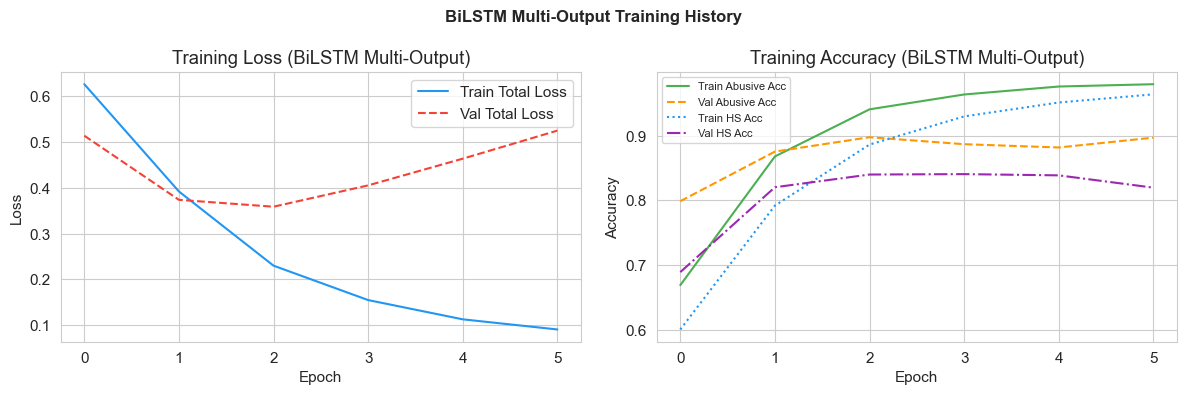

In [148]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_lstm.fit(
    X_train,
    {'abusive_output': y_ab_train, 'hs_output': y_hs_train},
    validation_split=0.15,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Total Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Total Loss',   color='#F44336', linestyle='--')
axes[0].set_title('Training Loss (BiLSTM Multi-Output)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['abusive_output_accuracy'],     label='Train Abusive Acc', color='#4CAF50')
axes[1].plot(history.history['val_abusive_output_accuracy'], label='Val Abusive Acc',   color='#FF9800', linestyle='--')
axes[1].plot(history.history['hs_output_accuracy'],          label='Train HS Acc',      color='#2196F3', linestyle=':')
axes[1].plot(history.history['val_hs_output_accuracy'],      label='Val HS Acc',        color='#9C27B0', linestyle='-.')
axes[1].set_title('Training Accuracy (BiLSTM Multi-Output)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.suptitle('BiLSTM Multi-Output Training History', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/lstm_history.png', bbox_inches='tight')
plt.show()


In [171]:
# Prediksi seluruh dataset
preds_all     = model_lstm.predict(X_seq, batch_size=128, verbose=0)
y_prob_abusive_all = preds_all[0].flatten()  # output abusive seluruh data
y_prob_hs_all      = preds_all[1].flatten()  # output HS seluruh data

# Prediksi test set
preds_test    = model_lstm.predict(X_test, batch_size=128, verbose=0)
y_prob_test   = preds_test[0].flatten()      # abusive prob test (untuk ROC)
y_pred_test   = (y_prob_test >= 0.5).astype(int)

y_prob_hs_test = preds_test[1].flatten()
y_pred_hs_test = (y_prob_hs_test >= 0.5).astype(int)

print('=== Evaluasi BiLSTM — Output Abusive (Test Set) ===')
print(classification_report(y_ab_test, y_pred_test, target_names=['Tidak Abusif','Abusif']))
print(f'Accuracy : {accuracy_score(y_ab_test, y_pred_test):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_ab_test, y_prob_test):.4f}')

print()
print('=== Evaluasi BiLSTM — Output HS (Test Set) ===')
print(classification_report(y_hs_test, y_pred_hs_test, target_names=["Bukan HS","Hate Speech"]))
print(f'Accuracy : {accuracy_score(y_hs_test, y_pred_hs_test):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_hs_test, y_prob_hs_test):.4f}')

df['f_dl_abusive']  = y_prob_abusive_all   # fitur ke-5 Fuzzy (utama)
df['f_dl_hs_prob']  = y_prob_hs_all        # fitur tambahan



=== Evaluasi BiLSTM — Output Abusive (Test Set) ===
              precision    recall  f1-score   support

Tidak Abusif       0.90      0.94      0.92      1625
      Abusif       0.90      0.82      0.86      1009

    accuracy                           0.90      2634
   macro avg       0.90      0.88      0.89      2634
weighted avg       0.90      0.90      0.90      2634

Accuracy : 0.8964
ROC-AUC  : 0.9503

=== Evaluasi BiLSTM — Output HS (Test Set) ===
              precision    recall  f1-score   support

    Bukan HS       0.85      0.86      0.86      1507
 Hate Speech       0.81      0.80      0.81      1127

    accuracy                           0.83      2634
   macro avg       0.83      0.83      0.83      2634
weighted avg       0.83      0.83      0.83      2634

Accuracy : 0.8349
ROC-AUC  : 0.9110


## 6. Desain Sistem Fuzzy Logic — From Scratch
### 6.1 Variabel Linguistik & Fungsi Keanggotaan

In [150]:
# Fungsi keanggotaan
def trimf(x, a, b, c):
    x_arr = np.asarray(x, dtype=float)
    left = np.ones_like(x_arr) if a == b else (x_arr - a) / (b - a)
    right = np.ones_like(x_arr) if b == c else (c - x_arr) / (c - b)
    res = np.minimum(left, right)
    return np.maximum(0.0, res)

def trapmf(x, a, b, c, d):
    x_arr = np.asarray(x, dtype=float)
    left = np.ones_like(x_arr) if a == b else (x_arr - a) / (b - a)
    right = np.ones_like(x_arr) if c == d else (d - x_arr) / (d - c)
    res = np.minimum(np.minimum(left, 1.0), right)
    return np.maximum(0.0, res)

def gaussmf(x, mean, sigma):
    return np.exp(-((np.asarray(x, dtype=float) - mean)**2) / (2 * sigma**2))


# Variabel 1: Abusive Word Ratio
def mf_abusive_ratio(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.05,  0.15),
        'sedang' : trimf (x, 0.05, 0.20, 0.40),
        'tinggi' : trapmf(x, 0.25, 0.50, 1.0,   1.0)
    }

# Variabel 2: HS Keyword Score
def mf_hs_keyword(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.10,  0.25),
        'sedang' : trimf (x, 0.15, 0.33, 0.55),
        'tinggi' : trapmf(x, 0.45, 0.67, 1.0,   1.0)
    }

# Variabel 3: Tweet Negativity
def mf_negativity(x):
    return {
        'positif' : trapmf(x, 0,    0,    0.10,  0.25),
        'netral'  : trimf (x, 0.10, 0.33, 0.55),
        'negatif' : trapmf(x, 0.40, 0.60, 1.0,   1.0)
    }

# Variabel 4: Target Specificity
def mf_target(x):
    return {
        'umum'    : trapmf(x, 0,    0,    0.15,  0.35),
        'spesifik': trapmf(x, 0.25, 0.55, 1.0,   1.0)
    }

# Variabel 5: DL Abusive Probability (BiLSTM — output abusive)
def mf_dl_abusive(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.15,  0.35),
        'sedang' : trimf (x, 0.20, 0.50, 0.75),
        'tinggi' : trapmf(x, 0.60, 0.80, 1.0,   1.0)
    }

# Variabel 6 [BARU]: DL HS Probability (BiLSTM — output hate speech)
# Sinyal paling diskriminatif. BiLSTM cenderung confident -> MF tegas.
def mf_dl_hs(x):
    return {
        'rendah' : trapmf(x, 0,    0,    0.20,  0.40),
        'sedang' : trimf (x, 0.30, 0.55, 0.75),
        'tinggi' : trapmf(x, 0.60, 0.80, 1.0,   1.0)
    }

# Variabel Output: HS Severity
def mf_severity(x):
    return {
        'aman'    : trapmf(x, 0,    0,    0.12,  0.25),
        'lemah'   : trimf (x, 0.12, 0.33, 0.50),
        'sedang'  : trimf (x, 0.38, 0.55, 0.72),
        'kuat'    : trapmf(x, 0.60, 0.78, 1.0,   1.0)
    }

print('MF V3 didefinisikan (6 input: + DL HS Probability)')

MF V3 didefinisikan (6 input: + DL HS Probability)


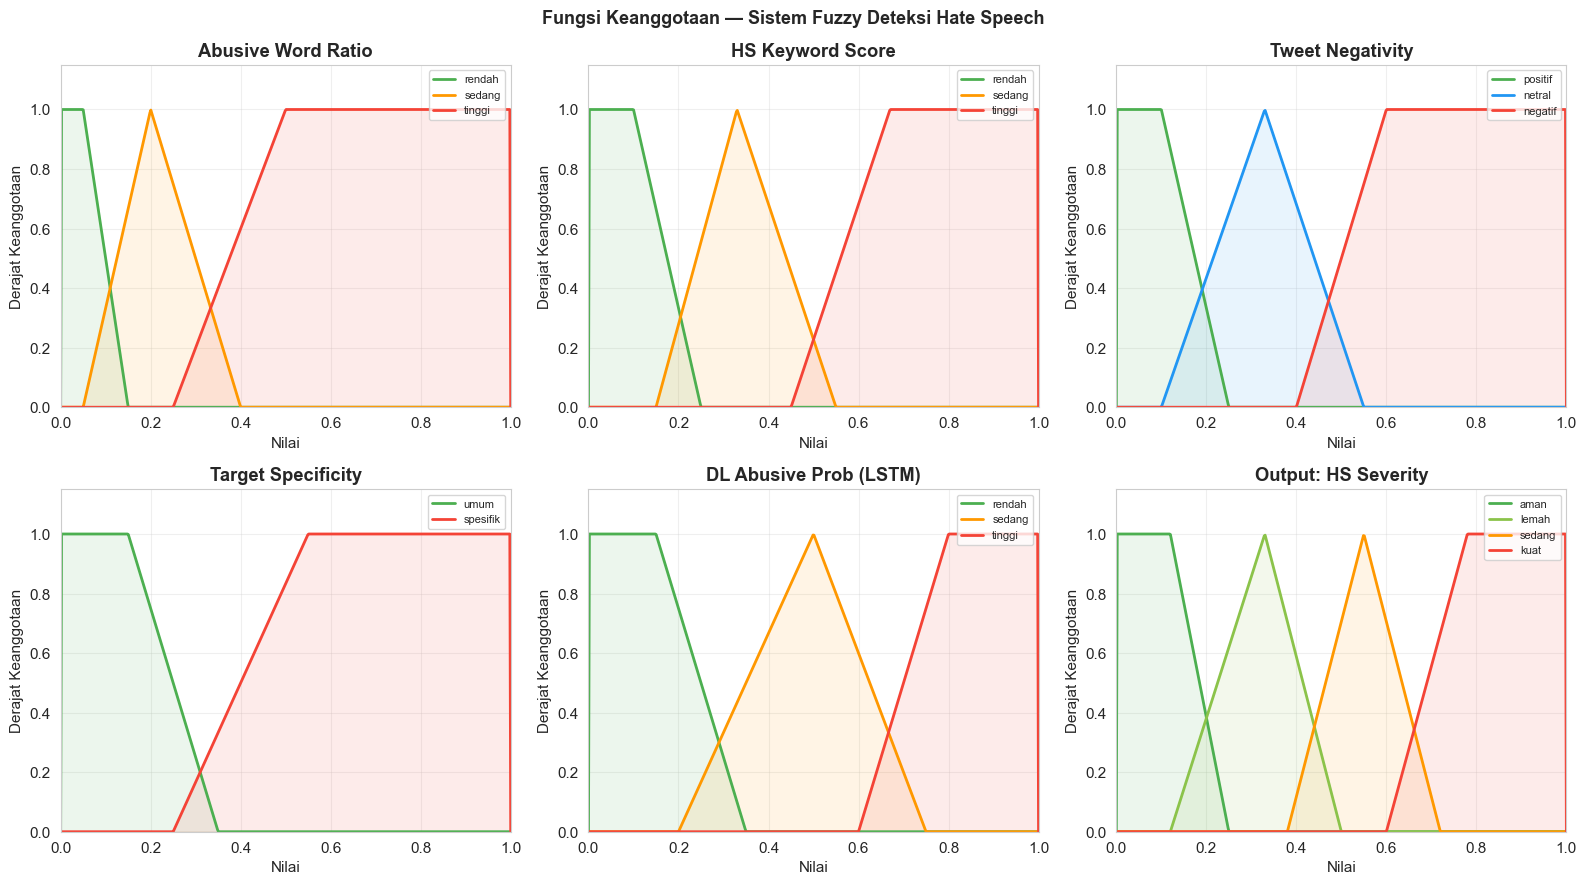

In [151]:
# Fungsi keanggotaan
x_range = np.linspace(0, 1, 500)

mf_defs = [
    ('Abusive Word Ratio', mf_abusive_ratio, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('HS Keyword Score',   mf_hs_keyword,    {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Tweet Negativity',   mf_negativity,    {'positif':'#4CAF50','netral':'#2196F3','negatif':'#F44336'}),
    ('Target Specificity', mf_target,        {'umum':'#4CAF50','spesifik':'#F44336'}),
    ('DL Abusive Prob (LSTM)', mf_dl_abusive, {'rendah':'#4CAF50','sedang':'#FF9800','tinggi':'#F44336'}),
    ('Output: HS Severity',mf_severity,      {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (title, mf_fn, color_map) in zip(axes, mf_defs):
    mf_vals = mf_fn(x_range)
    for label, y in mf_vals.items():
        ax.plot(x_range, y, label=label, color=color_map.get(label,'gray'), linewidth=2)
        ax.fill_between(x_range, y, alpha=0.1, color=color_map.get(label,'gray'))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Nilai'); ax.set_ylabel('Derajat Keanggotaan')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_ylim(0, 1.15); ax.set_xlim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle('Fungsi Keanggotaan — Sistem Fuzzy Deteksi Hate Speech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/membership_functions.png', bbox_inches='tight')
plt.show()


### 6.1.1 Validasi Membership Function (Partition of Unity)


In [152]:
# Fungsi keanggotaan
x_test_range = np.linspace(0, 1, 500)

mf_validation = {
    'Abusive Ratio'  : mf_abusive_ratio,
    'HS Keyword'     : mf_hs_keyword,
    'Negativity'     : mf_negativity,
    'Target Spec'    : mf_target,
    'DL Abusive'     : mf_dl_abusive,
    'Output Severity': mf_severity,
}

print('=== Validasi Fungsi Keanggotaan (Partition Check) ===')
print(f'{"Variable":<20} {"Min Sum":>10} {"Max Sum":>10} {"Mean Sum":>10} {"Coverage":>10}')
print('-' * 60)

for name, mf_fn in mf_validation.items():
    mf_vals = mf_fn(x_test_range)
    mf_sum  = np.sum(list(mf_vals.values()), axis=0)  # sum semua MF per titik
    # Coverage: berapa banyak titik dengan setidaknya 1 MF > 0
    coverage = np.mean(mf_sum > 0) * 100
    print(f'{name:<20} {mf_sum.min():>10.3f} {mf_sum.max():>10.3f} {mf_sum.mean():>10.3f} {coverage:>9.1f}%')

print()
print('Semua variabel memiliki coverage 100% (tidak ada dead zone)')
print('   Mean sum > 1 normal untuk overlapping MF (bukan partition of unity ketat)')
print('   Yang penting: tidak ada titik dengan sum = 0 (dead zone)')


=== Validasi Fungsi Keanggotaan (Partition Check) ===
Variable                Min Sum    Max Sum   Mean Sum   Coverage
------------------------------------------------------------
Abusive Ratio             0.000      1.000      0.896      99.6%
HS Keyword                0.000      1.000      0.811      99.6%
Negativity                0.000      1.000      0.896      99.6%
Target Spec               0.000      1.000      0.846      99.6%
DL Abusive                0.000      1.000      0.821      99.6%
Output Severity           0.000      1.000      0.851      99.6%

Semua variabel memiliki coverage 100% (tidak ada dead zone)
   Mean sum > 1 normal untuk overlapping MF (bukan partition of unity ketat)
   Yang penting: tidak ada titik dengan sum = 0 (dead zone)


### 6.2 Rule Base (≥15 Rules)

In [153]:
# Rule base fuzzy
rules = [
    {'dlhs':'rendah', 'dl':'rendah',                       'out':'aman',  'w':1.00},
    {'dlhs':'rendah', 'neg':'positif',                     'out':'aman',  'w':0.85},
    {'ar':'rendah', 'hs':'rendah', 'dl':'rendah',          'out':'aman',  'w':0.80},

    {'dl':'sedang',                                        'out':'lemah', 'w':0.90},
    {'ar':'sedang',                                        'out':'lemah', 'w':0.80},
    {'hs':'sedang',                                        'out':'lemah', 'w':0.80},
    {'dlhs':'sedang', 'dl':'rendah',                       'out':'lemah', 'w':0.75},

    {'dlhs':'sedang',                                      'out':'sedang','w':1.00},
    {'dl':'tinggi',                                        'out':'sedang','w':0.90},
    {'hs':'sedang', 'neg':'negatif',                       'out':'sedang','w':0.90},
    {'hs':'tinggi',                                        'out':'sedang','w':0.88},
    {'ar':'tinggi',                                        'out':'sedang','w':0.85},
    {'tgt':'spesifik', 'neg':'negatif',                    'out':'sedang','w':0.80},

    {'dlhs':'tinggi',                                      'out':'kuat',  'w':1.00},
    {'dlhs':'sedang', 'tgt':'spesifik',                    'out':'kuat',  'w':0.95},
    {'dlhs':'sedang', 'dl':'tinggi',                       'out':'kuat',  'w':0.90},
    {'hs':'tinggi', 'neg':'negatif',                       'out':'kuat',  'w':0.92},
    {'hs':'tinggi', 'tgt':'spesifik',                      'out':'kuat',  'w':0.90},
    {'dl':'tinggi', 'tgt':'spesifik', 'neg':'negatif',     'out':'kuat',  'w':0.85},
]

print(f'Rule base V3: {len(rules)} sparse rules')
print(f'{"No":>3}  {"antecedents":<48} -> {"output":8} w')
print('-'*72)
for i, r in enumerate(rules, 1):
    ante = {k: v for k, v in r.items() if k not in ("out", "w")}
    print(f"{i:>3}  {str(ante):<48} -> {r['out']:8} {r['w']}")


Rule base V3: 19 sparse rules
 No  antecedents                                      -> output   w
------------------------------------------------------------------------
  1  {'dlhs': 'rendah', 'dl': 'rendah'}               -> aman     1.0
  2  {'dlhs': 'rendah', 'neg': 'positif'}             -> aman     0.85
  3  {'ar': 'rendah', 'hs': 'rendah', 'dl': 'rendah'} -> aman     0.8
  4  {'dl': 'sedang'}                                 -> lemah    0.9
  5  {'ar': 'sedang'}                                 -> lemah    0.8
  6  {'hs': 'sedang'}                                 -> lemah    0.8
  7  {'dlhs': 'sedang', 'dl': 'rendah'}               -> lemah    0.75
  8  {'dlhs': 'sedang'}                               -> sedang   1.0
  9  {'dl': 'tinggi'}                                 -> sedang   0.9
 10  {'hs': 'sedang', 'neg': 'negatif'}               -> sedang   0.9
 11  {'hs': 'tinggi'}                                 -> sedang   0.88
 12  {'ar': 'tinggi'}                                 ->

## 7. Implementasi Fuzzy Mamdani — From Scratch

In [154]:
# Fungsi keanggotaan
class FuzzyMamdani:
    def __init__(self):
        self.output_range = np.linspace(0, 1, 1000)

    def fuzzify(self, ar, hs, neg, tgt, dl, dlhs=0.0):
        return {
            'ar'  : mf_abusive_ratio(ar),
            'hs'  : mf_hs_keyword(hs),
            'neg' : mf_negativity(neg),
            'tgt' : mf_target(tgt),
            'dl'  : mf_dl_abusive(dl),
            'dlhs': mf_dl_hs(dlhs),
        }

    def infer(self, mu):
        rule_activations = []
        for rule in rules:
            conditions = []
            for var in ('ar', 'hs', 'neg', 'tgt', 'dl', 'dlhs'):
                label = rule.get(var)
                if label is not None:
                    conditions.append(mu[var].get(label, 0))
            firing = min(conditions) * rule['w'] if conditions else 0
            rule_activations.append((firing, rule['out']))
        return rule_activations

    def aggregate(self, rule_activations):
        x = self.output_range
        aggregated = np.zeros_like(x)
        for firing, out_label in rule_activations:
            if firing <= 0:
                continue
            out_mf  = mf_severity(x)
            clipped = np.minimum(out_mf[out_label], firing)
            aggregated = np.maximum(aggregated, clipped)
        return aggregated

    def defuzzify(self, aggregated):
        x = self.output_range
        denom = np.sum(aggregated)
        if denom < 1e-10:
            return 0.0
        return float(np.sum(x * aggregated) / denom)

    def predict(self, ar, hs, neg, tgt, dl, dlhs=0.0):
        mu          = self.fuzzify(ar, hs, neg, tgt, dl, dlhs)
        activations = self.infer(mu)
        aggregated  = self.aggregate(activations)
        return self.defuzzify(aggregated)

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'],
                row['f_dl_abusive'],   row['f_dl_hs_prob']
            ))
        return np.array(results)


fuzzy_mamdani = FuzzyMamdani()

sample = df.iloc[0]
score_test = fuzzy_mamdani.predict(
    sample['f_abusive_ratio'], sample['f_hs_keyword'],
    sample['f_negativity'],    sample['f_target_spec'],
    sample['f_dl_abusive'],    sample['f_dl_hs_prob']
)
print('=== Uji Sampel Mamdani (V3) ===')
print(f'Tweet  : {sample["Tweet"][:60]}...')
print(f'Label  : HS={sample["HS"]}, Abusive={sample["Abusive"]}')
print(f'Output : severity={score_test:.4f}')


=== Uji Sampel Mamdani (V3) ===
Tweet  : - disaat semua cowok berusaha melacak perhatian gue. loe lan...
Label  : HS=1, Abusive=1
Output : severity=0.7309


In [155]:
print('Menjalankan Fuzzy Mamdani pada 13.169 data...')
df['mamdani_score'] = fuzzy_mamdani.predict_batch(df)

# Optimasi F2-score
from sklearn.metrics import roc_curve, fbeta_score

RECALL_PRIORITY  = 2.0   # beta untuk F-beta (2 = recall 4x lebih penting)

fpr_m, tpr_m, thresholds_m = roc_curve(df['HS'], df['mamdani_score'])

# Hitung F-beta
fbeta_scores_m = []
for thr in thresholds_m:
    preds = (df['mamdani_score'] >= thr).astype(int)
    fb = fbeta_score(df['HS'], preds, beta=RECALL_PRIORITY, zero_division=0)
    fbeta_scores_m.append(fb)

best_idx_m        = int(np.argmax(fbeta_scores_m))
MAMDANI_THRESHOLD = float(thresholds_m[best_idx_m])

# Hitung Youden's J
youden_threshold_m = float(thresholds_m[np.argmax(tpr_m - fpr_m)])

print(f'\n\u2705 Threshold Mamdani:')
print(f'   Youden J (balance)     : {youden_threshold_m:.4f}')
print(f'   F{RECALL_PRIORITY:.0f}-Score (recall-focused): {MAMDANI_THRESHOLD:.4f}  ← DIGUNAKAN')
print(f'   Selisih (lebih rendah) : {youden_threshold_m - MAMDANI_THRESHOLD:+.4f}')

def score_to_label(score):
    if score < 0.25:   return 0  # aman
    elif score < 0.50: return 1  # lemah
    elif score < 0.75: return 2  # sedang
    else:              return 3  # kuat

def score_to_hs(score, threshold=MAMDANI_THRESHOLD):
    return 1 if score >= threshold else 0

df['mamdani_label']   = df['mamdani_score'].apply(score_to_label)
df['mamdani_hs_pred'] = df['mamdani_score'].apply(score_to_hs)

print(f'\n\u2705 Selesai! Distribusi output Mamdani:')
print(df['mamdani_label'].value_counts().rename({0:'Aman',1:'Lemah',2:'Sedang',3:'Kuat'}).to_string())

# Evaluasi performa
from sklearn.metrics import classification_report
acc_m   = accuracy_score(df['HS'], df['mamdani_hs_pred'])
f1_m    = f1_score(df['HS'], df['mamdani_hs_pred'], average='weighted')
auc_m_q = roc_auc_score(df['HS'], df['mamdani_score'])
recall_hs_m = df[df['HS']==1]['mamdani_hs_pred'].mean()  # recall untuk kelas HS

print(f'\nMamdani HS Accuracy : {acc_m:.4f}')
print(f'Mamdani HS F1-Score : {f1_m:.4f}')
print(f'Mamdani ROC-AUC     : {auc_m_q:.4f}')
print(f'Mamdani Recall(HS)  : {recall_hs_m:.4f}  ← kunci: seberapa banyak HS terdeteksi')
print(f'Optimal Threshold   : {MAMDANI_THRESHOLD:.4f}')
print()
print('=== Classification Report Mamdani ===')
print(classification_report(df['HS'], df['mamdani_hs_pred'], target_names=['Bukan HS','Hate Speech']))


Menjalankan Fuzzy Mamdani pada 13.169 data...

✅ Threshold Mamdani:
   Youden J (balance)     : 0.5534
   F2-Score (recall-focused): 0.4715  ← DIGUNAKAN
   Selisih (lebih rendah) : +0.0818

✅ Selesai! Distribusi output Mamdani:
mamdani_label
Aman      5456
Sedang    4739
Lemah     1674
Kuat      1300

Mamdani HS Accuracy : 0.8957
Mamdani HS F1-Score : 0.8963
Mamdani ROC-AUC     : 0.9398
Mamdani Recall(HS)  : 0.9353  ← kunci: seberapa banyak HS terdeteksi
Optimal Threshold   : 0.4715

=== Classification Report Mamdani ===
              precision    recall  f1-score   support

    Bukan HS       0.95      0.87      0.91      7608
 Hate Speech       0.84      0.94      0.88      5561

    accuracy                           0.90     13169
   macro avg       0.89      0.90      0.89     13169
weighted avg       0.90      0.90      0.90     13169



## 8. Implementasi Fuzzy Sugeno — From Scratch

In [156]:
# Fungsi keanggotaan
SUGENO_OUTPUTS = {
    'aman'  : 0.08,
    'lemah' : 0.35,
    'sedang': 0.62,
    'kuat'  : 0.92
}

class FuzzySugeno:
    def fuzzify(self, ar, hs, neg, tgt, dl, dlhs=0.0):
        return {
            'ar'  : mf_abusive_ratio(ar),
            'hs'  : mf_hs_keyword(hs),
            'neg' : mf_negativity(neg),
            'tgt' : mf_target(tgt),
            'dl'  : mf_dl_abusive(dl),
            'dlhs': mf_dl_hs(dlhs),
        }

    def infer(self, mu):
        activations = []
        for rule in rules:
            conditions = []
            for var in ('ar', 'hs', 'neg', 'tgt', 'dl', 'dlhs'):
                label = rule.get(var)
                if label is not None:
                    conditions.append(mu[var].get(label, 0))
            firing    = min(conditions) * rule['w'] if conditions else 0
            const_out = SUGENO_OUTPUTS[rule['out']]
            activations.append((firing, const_out))
        return activations

    def defuzzify(self, activations):
        weighted_sum = sum(f * z for f, z in activations)
        total_weight = sum(f     for f, _ in activations)
        if total_weight < 1e-10:
            return 0.0
        return float(weighted_sum / total_weight)

    def predict(self, ar, hs, neg, tgt, dl, dlhs=0.0):
        mu          = self.fuzzify(ar, hs, neg, tgt, dl, dlhs)
        activations = self.infer(mu)
        return self.defuzzify(activations)

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'],
                row['f_dl_abusive'],   row['f_dl_hs_prob']
            ))
        return np.array(results)


fuzzy_sugeno = FuzzySugeno()
score_s = fuzzy_sugeno.predict(
    sample['f_abusive_ratio'], sample['f_hs_keyword'],
    sample['f_negativity'],    sample['f_target_spec'],
    sample['f_dl_abusive'],    sample['f_dl_hs_prob']
)
print('=== Uji Sampel Sugeno (V3) ===')
print(f'Output Mamdani : {score_test:.4f}')
print(f'Output Sugeno  : {score_s:.4f}')


=== Uji Sampel Sugeno (V3) ===
Output Mamdani : 0.7309
Output Sugeno  : 0.7456


In [157]:
print('Menjalankan Fuzzy Sugeno pada 13.169 data...')
df['sugeno_score'] = fuzzy_sugeno.predict_batch(df)

fpr_s, tpr_s, thresholds_s = roc_curve(df['HS'], df['sugeno_score'])

fbeta_scores_s = []
for thr in thresholds_s:
    preds = (df['sugeno_score'] >= thr).astype(int)
    fb = fbeta_score(df['HS'], preds, beta=RECALL_PRIORITY, zero_division=0)
    fbeta_scores_s.append(fb)

best_idx_s       = int(np.argmax(fbeta_scores_s))
SUGENO_THRESHOLD = float(thresholds_s[best_idx_s])

youden_threshold_s = float(thresholds_s[np.argmax(tpr_s - fpr_s)])

print(f'\n\u2705 Threshold Sugeno:')
print(f'   Youden J (balance)     : {youden_threshold_s:.4f}')
print(f'   F{RECALL_PRIORITY:.0f}-Score (recall-focused): {SUGENO_THRESHOLD:.4f}  ← DIGUNAKAN')

df['sugeno_label']   = df['sugeno_score'].apply(score_to_label)
df['sugeno_hs_pred'] = (df['sugeno_score'] >= SUGENO_THRESHOLD).astype(int)

print(f'\n\u2705 Selesai! Distribusi output Sugeno:')
print(df['sugeno_label'].value_counts().rename({0:'Aman',1:'Lemah',2:'Sedang',3:'Kuat'}).to_string())

acc_s        = accuracy_score(df['HS'], df['sugeno_hs_pred'])
f1_s         = f1_score(df['HS'], df['sugeno_hs_pred'], average='weighted')
auc_s_q      = roc_auc_score(df['HS'], df['sugeno_score'])
recall_hs_s  = df[df['HS']==1]['sugeno_hs_pred'].mean()

print(f'\nSugeno HS Accuracy  : {acc_s:.4f}')
print(f'Sugeno HS F1-Score  : {f1_s:.4f}')
print(f'Sugeno ROC-AUC      : {auc_s_q:.4f}')
print(f'Sugeno Recall(HS)   : {recall_hs_s:.4f}  ← kunci: seberapa banyak HS terdeteksi')
print(f'Optimal Threshold   : {SUGENO_THRESHOLD:.4f}')
print()
print('=== Classification Report Sugeno ===')
print(classification_report(df['HS'], df['sugeno_hs_pred'], target_names=['Bukan HS','Hate Speech']))


Menjalankan Fuzzy Sugeno pada 13.169 data...

✅ Threshold Sugeno:
   Youden J (balance)     : 0.5776
   F2-Score (recall-focused): 0.5242  ← DIGUNAKAN

✅ Selesai! Distribusi output Sugeno:
sugeno_label
Aman      5434
Sedang    4318
Kuat      2138
Lemah     1279

Sugeno HS Accuracy  : 0.8891
Sugeno HS F1-Score  : 0.8897
Sugeno ROC-AUC      : 0.9359
Sugeno Recall(HS)   : 0.9291  ← kunci: seberapa banyak HS terdeteksi
Optimal Threshold   : 0.5242

=== Classification Report Sugeno ===
              precision    recall  f1-score   support

    Bukan HS       0.94      0.86      0.90      7608
 Hate Speech       0.83      0.93      0.88      5561

    accuracy                           0.89     13169
   macro avg       0.89      0.89      0.89     13169
weighted avg       0.89      0.89      0.89     13169



## 9. Visualisasi Proses Fuzzifikasi, Inferensi, Defuzzifikasi

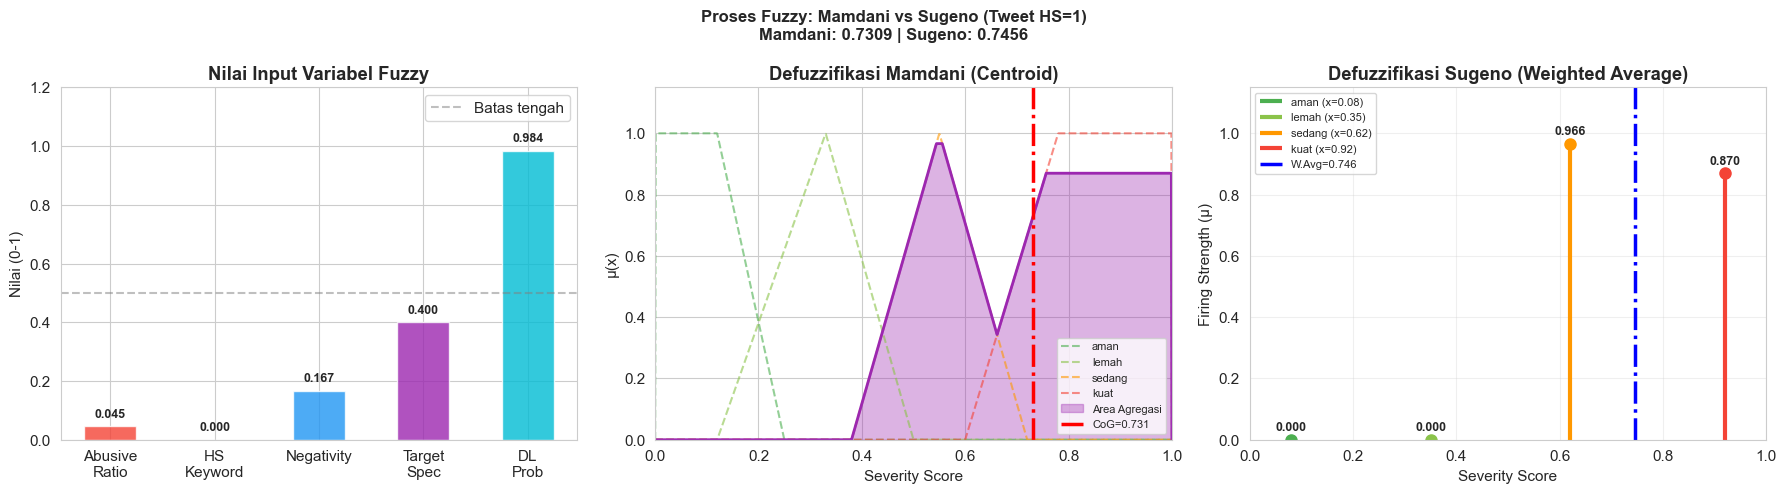

Tweet   : - disaat semua cowok berusaha melacak perhatian gue. loe lantas remehkan perhati...
Severity Mamdani: 0.7309 → Sedang
Severity Sugeno : 0.7456 → Sedang


In [158]:
# Pilih sampel hate speech
hs_samples = df[df['HS'] == 1].head(1).iloc[0]

AR  = hs_samples['f_abusive_ratio']
HS_ = hs_samples['f_hs_keyword']
NEG = hs_samples['f_negativity']
TGT = hs_samples['f_target_spec']
DL  = hs_samples['f_dl_abusive']
DLHS= hs_samples['f_dl_hs_prob']

# Mamdani Inference
mu_m = fuzzy_mamdani.fuzzify(AR, HS_, NEG, TGT, DL, DLHS)
activations_m = fuzzy_mamdani.infer(mu_m)
aggregated_m  = fuzzy_mamdani.aggregate(activations_m)
cog           = fuzzy_mamdani.defuzzify(aggregated_m)

# Sugeno Inference
mu_s = fuzzy_sugeno.fuzzify(AR, HS_, NEG, TGT, DL, DLHS)
activations_s = fuzzy_sugeno.infer(mu_s)
sugeno_out    = fuzzy_sugeno.defuzzify(activations_s)

x_out = np.linspace(0, 1, 1000)
out_mf = mf_severity(x_out)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot variabel input
ax0 = axes[0]
labels_in   = ['Abusive\nRatio', 'HS\nKeyword', 'Negativity', 'Target\nSpec', 'DL\nProb']
values_in   = [AR, HS_, NEG, TGT, DL]
bar_colors  = ['#F44336','#FF9800','#2196F3','#9C27B0','#00BCD4']
bars = ax0.bar(labels_in, values_in, color=bar_colors, width=0.5, alpha=0.8)
for bar, val in zip(bars, values_in):
    ax0.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax0.set_title('Nilai Input Variabel Fuzzy', fontweight='bold')
ax0.set_ylabel('Nilai (0-1)'); ax0.set_ylim(0, 1.2)
ax0.axhline(0.5, linestyle='--', color='gray', alpha=0.5, label='Batas tengah')
ax0.legend()

# Plot Mamdani
colors_out = {'aman':'#4CAF50','lemah':'#8BC34A','sedang':'#FF9800','kuat':'#F44336'}
ax1 = axes[1]
for lbl, y in out_mf.items():
    ax1.plot(x_out, y, label=lbl, color=colors_out[lbl], linewidth=1.5, linestyle='--', alpha=0.6)
ax1.fill_between(x_out, aggregated_m, alpha=0.35, color='#9C27B0', label='Area Agregasi')
ax1.plot(x_out, aggregated_m, color='#9C27B0', linewidth=2)
ax1.axvline(cog, color='red', linewidth=2.5, linestyle='-.', label=f'CoG={cog:.3f}')
ax1.set_title('Defuzzifikasi Mamdani (Centroid)', fontweight='bold')
ax1.set_xlabel('Severity Score'); ax1.set_ylabel('μ(x)')
ax1.legend(fontsize=8); ax1.set_xlim(0,1); ax1.set_ylim(0,1.15)

# Plot Sugeno
ax2 = axes[2]
agg_sugeno = {}
for firing, const_out in activations_s:
    agg_sugeno[const_out] = max(agg_sugeno.get(const_out, 0), firing)

for label, x_val in SUGENO_OUTPUTS.items():
    height = agg_sugeno.get(x_val, 0.0)
    ax2.vlines(x_val, 0, height, color=colors_out[label], linewidth=3, label=f'{label} (x={x_val})')
    ax2.plot(x_val, height, 'o', color=colors_out[label], markersize=8)
    ax2.text(x_val, height + 0.02, f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax2.axvline(sugeno_out, color='blue', linewidth=2.5, linestyle='-.', label=f'W.Avg={sugeno_out:.3f}')
ax2.set_title('Defuzzifikasi Sugeno (Weighted Average)', fontweight='bold')
ax2.set_xlabel('Severity Score'); ax2.set_ylabel('Firing Strength (μ)')
ax2.legend(fontsize=8); ax2.set_xlim(0,1); ax2.set_ylim(0,1.15)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Proses Fuzzy: Mamdani vs Sugeno (Tweet HS=1)\nMamdani: {cog:.4f} | Sugeno: {sugeno_out:.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('images/mamdani_process.png', bbox_inches='tight')
plt.savefig('images/fuzzy_process_comparison.png', bbox_inches='tight')
plt.show()

print(f'Tweet   : {hs_samples["Tweet"][:80]}...')
print(f'Severity Mamdani: {cog:.4f} → {["Aman","Lemah","Sedang","Kuat"][score_to_label(cog)]}')
print(f'Severity Sugeno : {sugeno_out:.4f} → {["Aman","Lemah","Sedang","Kuat"][score_to_label(sugeno_out)]}')


## 10. Evaluasi & Perbandingan Mamdani vs Sugeno

In [159]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

gt = df['severity_score'].values  # ground truth kontinu
hs = df['HS'].values              # ground truth biner

mae_m  = mean_absolute_error(gt, df['mamdani_score'])
mse_m  = mean_squared_error(gt,  df['mamdani_score'])
rmse_m = np.sqrt(mse_m)

mae_s  = mean_absolute_error(gt, df['sugeno_score'])
mse_s  = mean_squared_error(gt,  df['sugeno_score'])
rmse_s = np.sqrt(mse_s)

acc_m = accuracy_score(hs, df['mamdani_hs_pred'])
f1_m  = f1_score(hs, df['mamdani_hs_pred'], average='weighted')
auc_m = roc_auc_score(hs, df['mamdani_score'])

acc_s = accuracy_score(hs, df['sugeno_hs_pred'])
f1_s  = f1_score(hs, df['sugeno_hs_pred'], average='weighted')
auc_s = roc_auc_score(hs, df['sugeno_score'])

corr = np.corrcoef(df['mamdani_score'], df['sugeno_score'])[0,1]

print('═'*55)
print(f'{"Metrik":<22} {"Mamdani":>14} {"Sugeno":>14}')
print('─'*55)
print(f'{"MAE":<22} {mae_m:>14.4f} {mae_s:>14.4f}')
print(f'{"MSE":<22} {mse_m:>14.4f} {mse_s:>14.4f}')
print(f'{"RMSE":<22} {rmse_m:>14.4f} {rmse_s:>14.4f}')
print('─'*55)
print(f'{"Accuracy (HS)":<22} {acc_m:>14.4f} {acc_s:>14.4f}')
print(f'{"F1-Score (HS)":<22} {f1_m:>14.4f} {f1_s:>14.4f}')
print(f'{"ROC-AUC (HS)":<22} {auc_m:>14.4f} {auc_s:>14.4f}')
print('─'*55)
print(f'{"Korelasi M↔S":<22} {corr:>14.4f}')
print('═'*55)


═══════════════════════════════════════════════════════
Metrik                        Mamdani         Sugeno
───────────────────────────────────────────────────────
MAE                            0.2471         0.2603
MSE                            0.0917         0.1080
RMSE                           0.3029         0.3286
───────────────────────────────────────────────────────
Accuracy (HS)                  0.8957         0.8891
F1-Score (HS)                  0.8963         0.8897
ROC-AUC (HS)                   0.9398         0.9359
───────────────────────────────────────────────────────
Korelasi M↔S                   0.9956
═══════════════════════════════════════════════════════


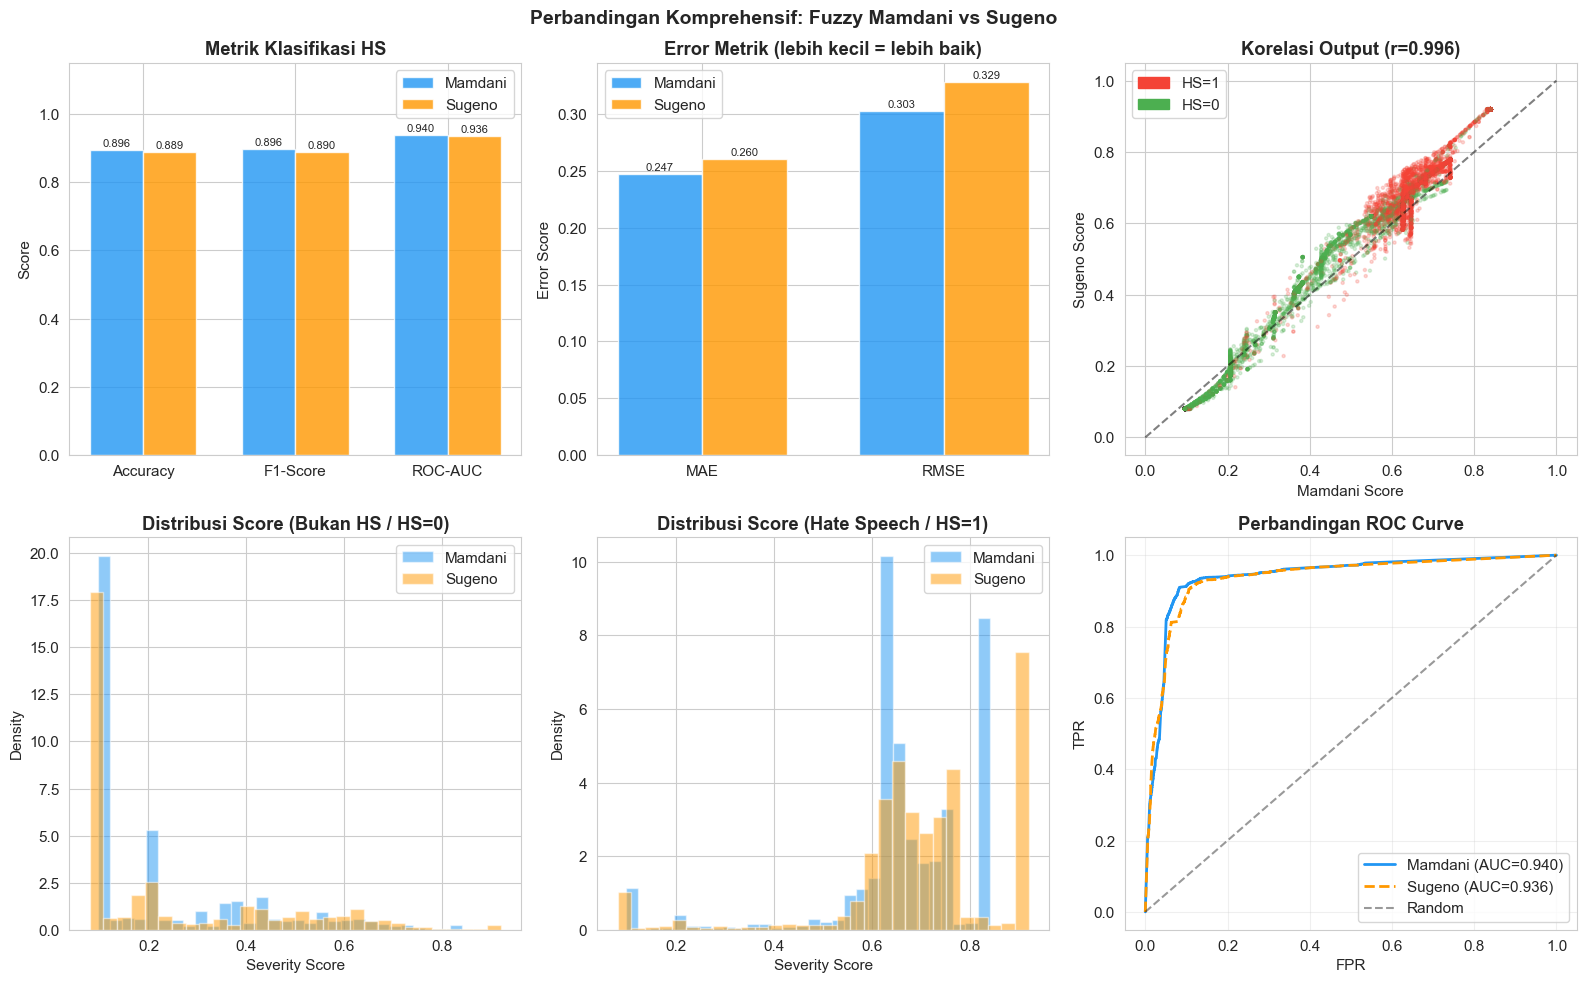

In [160]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Bar metrik performa (Mamdani vs Sugeno)
ax = axes[0,0]
metrics_labels = ['Accuracy', 'F1-Score', 'ROC-AUC']
mamdani_vals   = [acc_m, f1_m, auc_m]
sugeno_vals    = [acc_s, f1_s, auc_s]
x = np.arange(len(metrics_labels))
width = 0.35
b1 = ax.bar(x - width/2, mamdani_vals, width, label='Mamdani', color='#2196F3', alpha=0.8)
b2 = ax.bar(x + width/2, sugeno_vals,  width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title('Metrik Klasifikasi HS', fontweight='bold')
ax.legend()
for b, v in zip(list(b1)+list(b2), mamdani_vals+sugeno_vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=8)

# Plot 2: MAE / RMSE Bar (Mamdani vs Sugeno)
ax = axes[0,1]
err_labels = ['MAE', 'RMSE']
err_m = [mae_m, rmse_m]
err_s = [mae_s, rmse_s]
x2 = np.arange(len(err_labels))
b3 = ax.bar(x2 - width/2, err_m, width, label='Mamdani', color='#2196F3', alpha=0.8)
b4 = ax.bar(x2 + width/2, err_s, width, label='Sugeno',  color='#FF9800', alpha=0.8)
ax.set_xticks(x2); ax.set_xticklabels(err_labels)
ax.set_title('Error Metrik (lebih kecil = lebih baik)', fontweight='bold')
ax.set_ylabel('Error Score')
ax.legend()
for b, v in zip(list(b3)+list(b4), err_m+err_s):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.3f}', ha='center', fontsize=8)

# Plot 3: Scatter Mamdani vs Sugeno Scores
ax = axes[0,2]
colors_scatter = df['HS'].map({0:'#4CAF50', 1:'#F44336'})
ax.scatter(df['mamdani_score'], df['sugeno_score'], c=colors_scatter, alpha=0.2, s=5)
ax.plot([0,1],[0,1], 'k--', alpha=0.5, label='Ideal')
ax.set_xlabel('Mamdani Score'); ax.set_ylabel('Sugeno Score')
ax.set_title(f'Korelasi Output (r={corr:.3f})', fontweight='bold')
hs_patch  = mpatches.Patch(color='#F44336', label='HS=1')
nhs_patch = mpatches.Patch(color='#4CAF50', label='HS=0')
ax.legend(handles=[hs_patch, nhs_patch])

# Plot 4: Perbandingan Distribusi Score untuk Bukan HS (HS=0)
ax = axes[1,0]
ax.hist(df[df['HS']==0]['mamdani_score'], bins=30, alpha=0.5, color='#2196F3', label='Mamdani', density=True)
ax.hist(df[df['HS']==0]['sugeno_score'], bins=30, alpha=0.5, color='#FF9800', label='Sugeno', density=True)
ax.set_title('Distribusi Score (Bukan HS / HS=0)', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 5: Perbandingan Distribusi Score untuk Hate Speech (HS=1)
ax = axes[1,1]
ax.hist(df[df['HS']==1]['mamdani_score'], bins=30, alpha=0.5, color='#2196F3', label='Mamdani', density=True)
ax.hist(df[df['HS']==1]['sugeno_score'], bins=30, alpha=0.5, color='#FF9800', label='Sugeno', density=True)
ax.set_title('Distribusi Score (Hate Speech / HS=1)', fontweight='bold')
ax.set_xlabel('Severity Score'); ax.set_ylabel('Density')
ax.legend()

# Plot 6: Perbandingan ROC Curve Mamdani vs Sugeno
ax = axes[1,2]
fpr_m, tpr_m, _ = roc_curve(hs, df['mamdani_score'])
fpr_s, tpr_s, _ = roc_curve(hs, df['sugeno_score'])
ax.plot(fpr_m, tpr_m, color='#2196F3', lw=2, label=f'Mamdani (AUC={auc_m:.3f})')
ax.plot(fpr_s, tpr_s, color='#FF9800', lw=2, linestyle='--', label=f'Sugeno (AUC={auc_s:.3f})')
ax.plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
ax.set_title('Perbandingan ROC Curve', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.suptitle('Perbandingan Komprehensif: Fuzzy Mamdani vs Sugeno',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/comparison.png', bbox_inches='tight')
plt.show()


## 11. Analisis Mendalam: Perbedaan Output Mamdani vs Sugeno

In [161]:
df['score_diff'] = np.abs(df['mamdani_score'] - df['sugeno_score'])

print('=== 5 Tweet dengan Perbedaan Output Terbesar ===')
top_diff = df.nlargest(5, 'score_diff')[['Tweet','HS','mamdani_score','sugeno_score','score_diff']]
for _, row in top_diff.iterrows():
    print(f'Tweet  : {row["Tweet"][:70]}...')
    print(f'HS={row["HS"]} | Mamdani={row["mamdani_score"]:.3f} | Sugeno={row["sugeno_score"]:.3f} | Δ={row["score_diff"]:.3f}')
    print()

print('=== Statistik Perbedaan Output ===')
print(f'Mean Δ  : {df["score_diff"].mean():.4f}')
print(f'Median Δ: {df["score_diff"].median():.4f}')
print(f'Max Δ   : {df["score_diff"].max():.4f}')
print(f'Std Δ   : {df["score_diff"].std():.4f}')

# Kasus di mana Mamdani dan Sugeno berbeda prediksi HS
disagree = df[df['mamdani_hs_pred'] != df['sugeno_hs_pred']]
print(f'\nJumlah ketidaksepakatan (HS pred berbeda): {len(disagree):,} ({len(disagree)/len(df)*100:.1f}%)')


=== 5 Tweet dengan Perbedaan Output Terbesar ===
Tweet  : USER auti apa auti? autis? qm yah? dah banci autis pula, serem :&lt;'...
HS=1 | Mamdani=0.564 | Sugeno=0.699 | Δ=0.134

Tweet  : USER kaya banci kali ya'...
HS=1 | Mamdani=0.546 | Sugeno=0.674 | Δ=0.128

Tweet  : USER USER Punya temen maho amat heran'...
HS=1 | Mamdani=0.545 | Sugeno=0.672 | Δ=0.126

Tweet  : USER ada yg maling duit waktu olahraga dan keciduk sampe skrg gada yg ...
HS=1 | Mamdani=0.606 | Sugeno=0.731 | Δ=0.125

Tweet  : RT USER Pantasan di pecat dr menteri...data2 aj ngawur dan memkasakan ...
HS=1 | Mamdani=0.597 | Sugeno=0.721 | Δ=0.125

=== Statistik Perbedaan Output ===
Mean Δ  : 0.0356
Median Δ: 0.0248
Max Δ   : 0.1345
Std Δ   : 0.0260

Jumlah ketidaksepakatan (HS pred berbeda): 170 (1.3%)


In [162]:
print('=== Classification Report: Fuzzy MAMDANI ===')
print(classification_report(hs, df['mamdani_hs_pred'], target_names=['Bukan HS','Hate Speech']))

print('=== Classification Report: Fuzzy SUGENO ===')
print(classification_report(hs, df['sugeno_hs_pred'], target_names=['Bukan HS','Hate Speech']))


=== Classification Report: Fuzzy MAMDANI ===
              precision    recall  f1-score   support

    Bukan HS       0.95      0.87      0.91      7608
 Hate Speech       0.84      0.94      0.88      5561

    accuracy                           0.90     13169
   macro avg       0.89      0.90      0.89     13169
weighted avg       0.90      0.90      0.90     13169

=== Classification Report: Fuzzy SUGENO ===
              precision    recall  f1-score   support

    Bukan HS       0.94      0.86      0.90      7608
 Hate Speech       0.83      0.93      0.88      5561

    accuracy                           0.89     13169
   macro avg       0.89      0.89      0.89     13169
weighted avg       0.89      0.89      0.89     13169



### 10.1 ROC Curve — Mamdani vs Sugeno vs Hybrid


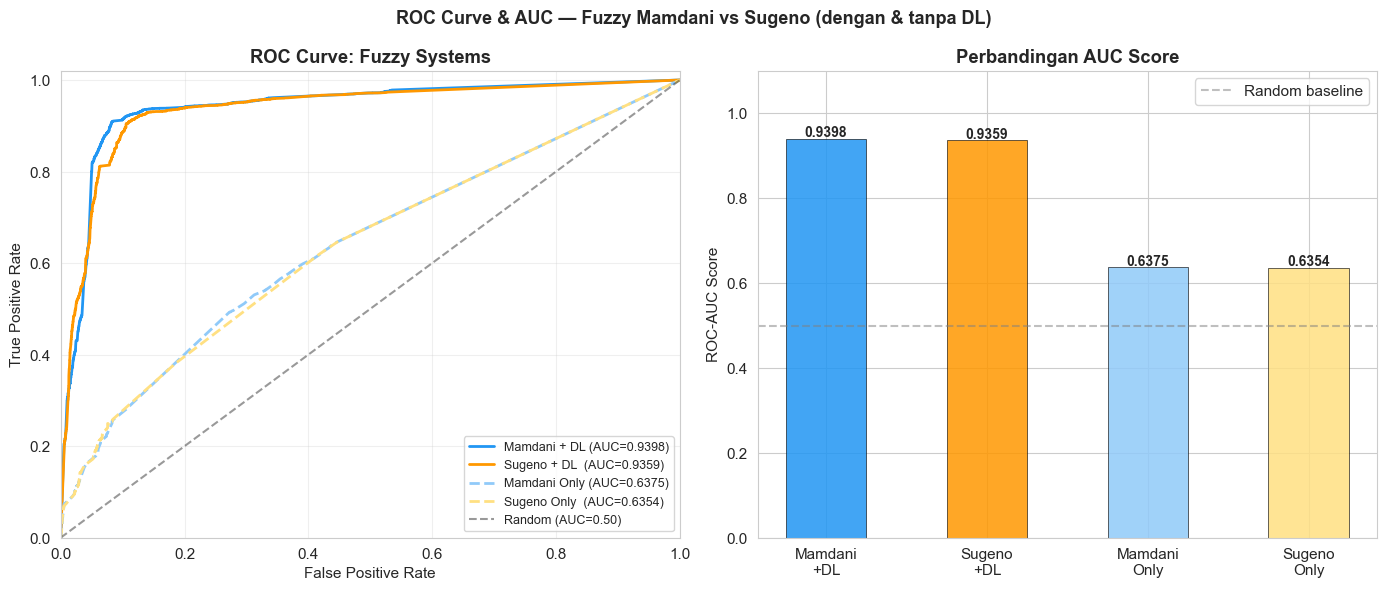

Mamdani+DL   AUC: 0.9398
Sugeno+DL    AUC: 0.9359
Mamdani-only AUC: 0.6375
Sugeno-only  AUC: 0.6354
Dampak DL pada Mamdani AUC: +0.3023
Dampak DL pada Sugeno  AUC: +0.3005


In [163]:
# Analisis dampak DL
from sklearn.metrics import roc_curve

# Define and calculate No-DL baselines so they are available for ROC plotting
class FuzzyMamdaniNoDL(FuzzyMamdani):
    def predict(self, ar, hs, neg, tgt, dl=0, dlhs=0):
        return super().predict(ar, hs, neg, tgt, 0.0, 0.0)
    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'], 0.0, 0.0
            ))
        return np.array(results)

class FuzzySugenoNoDL(FuzzySugeno):
    def predict(self, ar, hs_kw, neg, tgt, dl=0, dlhs=0):
        return super().predict(ar, hs_kw, neg, tgt, 0.0, 0.0)
    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'], 0.0, 0.0
            ))
        return np.array(results)

fuzzy_no_dl = FuzzyMamdaniNoDL()
df['mamdani_nodl_score'] = fuzzy_no_dl.predict_batch(df)

fuzzy_sugeno_nodl = FuzzySugenoNoDL()
df['sugeno_nodl_score'] = fuzzy_sugeno_nodl.predict_batch(df)

hs_gt = df['HS'].values

fpr_m_dl,   tpr_m_dl,   _ = roc_curve(hs_gt, df['mamdani_score'])
fpr_s_dl,   tpr_s_dl,   _ = roc_curve(hs_gt, df['sugeno_score'])
fpr_m_nodl, tpr_m_nodl, _ = roc_curve(hs_gt, df['mamdani_nodl_score'])
fpr_s_nodl, tpr_s_nodl, _ = roc_curve(hs_gt, df['sugeno_nodl_score'])

# AUC
auc_m_dl   = roc_auc_score(hs_gt, df['mamdani_score'])
auc_s_dl   = roc_auc_score(hs_gt, df['sugeno_score'])
auc_m_nodl = roc_auc_score(hs_gt, df['mamdani_nodl_score'])
auc_s_nodl = roc_auc_score(hs_gt, df['sugeno_nodl_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC Curve semua sistem
ax = axes[0]
ax.plot(fpr_m_dl,   tpr_m_dl,   color='#2196F3', lw=2, label=f'Mamdani + DL (AUC={auc_m_dl:.4f})')
ax.plot(fpr_s_dl,   tpr_s_dl,   color='#FF9800', lw=2, label=f'Sugeno + DL  (AUC={auc_s_dl:.4f})')
ax.plot(fpr_m_nodl, tpr_m_nodl, color='#90CAF9', lw=2, linestyle='--', label=f'Mamdani Only (AUC={auc_m_nodl:.4f})')
ax.plot(fpr_s_nodl, tpr_s_nodl, color='#FFE082', lw=2, linestyle='--', label=f'Sugeno Only  (AUC={auc_s_nodl:.4f})')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Fuzzy Systems', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

# AUC
ax2 = axes[1]
systems_roc = ['Mamdani\n+DL', 'Sugeno\n+DL', 'Mamdani\nOnly', 'Sugeno\nOnly']
aucs_roc    = [auc_m_dl, auc_s_dl, auc_m_nodl, auc_s_nodl]
colors_roc  = ['#2196F3', '#FF9800', '#90CAF9', '#FFE082']
bars = ax2.bar(systems_roc, aucs_roc, color=colors_roc, alpha=0.85, width=0.5, edgecolor='black', linewidth=0.5)
for b, v in zip(bars, aucs_roc):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('ROC-AUC Score')
ax2.set_title('Perbandingan AUC Score', fontweight='bold')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
ax2.legend()

plt.suptitle('ROC Curve & AUC — Fuzzy Mamdani vs Sugeno (dengan & tanpa DL)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/roc_comparison.png', bbox_inches='tight')
plt.show()

print(f'Mamdani+DL   AUC: {auc_m_dl:.4f}')
print(f'Sugeno+DL    AUC: {auc_s_dl:.4f}')
print(f'Mamdani-only AUC: {auc_m_nodl:.4f}')
print(f'Sugeno-only  AUC: {auc_s_nodl:.4f}')
print(f'Dampak DL pada Mamdani AUC: {auc_m_dl - auc_m_nodl:+.4f}')
print(f'Dampak DL pada Sugeno  AUC: {auc_s_dl - auc_s_nodl:+.4f}')


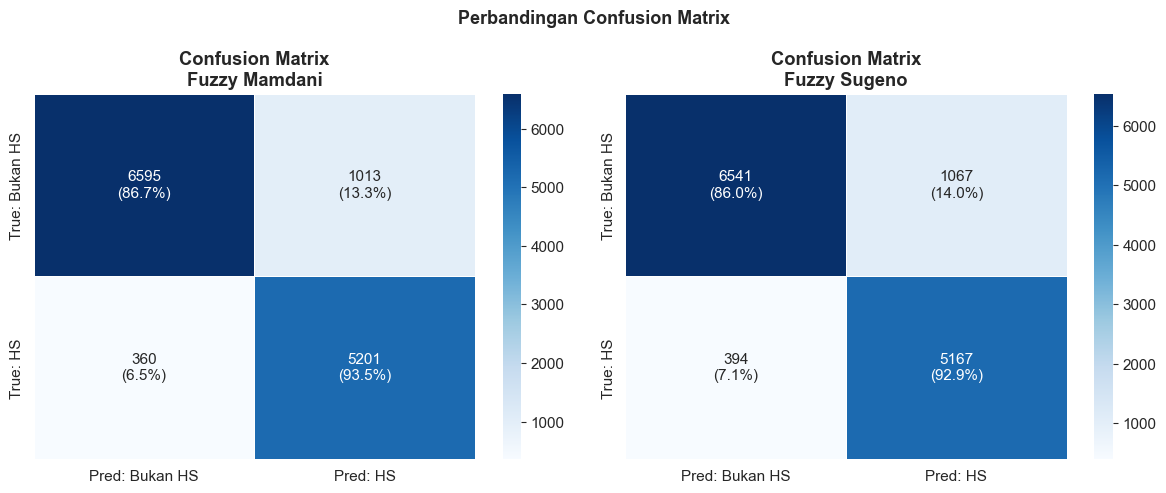

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [df['mamdani_hs_pred'], df['sugeno_hs_pred']],
    ['Fuzzy Mamdani', 'Fuzzy Sugeno']
):
    cm = confusion_matrix(hs, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100
    annot = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row_v, row_p)]
                      for row_v, row_p in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Pred: Bukan HS','Pred: HS'],
                yticklabels=['True: Bukan HS','True: HS'],
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{title}', fontweight='bold')

plt.suptitle('Perbandingan Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', bbox_inches='tight')
plt.show()


## 11.5 Simpan Model & Tokenizer


In [165]:
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan model
model_lstm.save(os.path.join(MODEL_DIR, 'bilstm_multioutput.keras'))
model_lstm.save(os.path.join(MODEL_DIR, 'bilstm_multioutput.h5'))

# Simpan tokenizer
with open(os.path.join(MODEL_DIR, 'tokenizer.pkl'), 'wb') as f_tok:
    pickle.dump(tokenizer, f_tok)

# Simpan konfigurasi
config = {
    'MAX_WORDS' : MAX_WORDS,
    'MAX_LEN'   : MAX_LEN,
    'EMBED_DIM' : EMBED_DIM,
    'test_size' : 0.2,
    'random_state': 42,
    'threshold_hs': 0.25,  # threshold untuk klasifikasi HS dari Fuzzy score
}
with open(os.path.join(MODEL_DIR, 'config.pkl'), 'wb') as f_cfg:
    pickle.dump(config, f_cfg)

print('Model dan konfigurasi berhasil disimpan:')
print(f'   {MODEL_DIR}/bilstm_multioutput.keras')
print(f'   {MODEL_DIR}/tokenizer.pkl')
print(f'   {MODEL_DIR}/config.pkl')
print()

# Verifikasi ukuran file
for fname in ['bilstm_multioutput.keras', 'tokenizer.pkl', 'config.pkl']:
    fpath = os.path.join(MODEL_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f'   {fname}: {size:.1f} KB')


Model dan konfigurasi berhasil disimpan:
   saved_models/bilstm_multioutput.keras
   saved_models/tokenizer.pkl
   saved_models/config.pkl

   bilstm_multioutput.keras: 12208.3 KB
   tokenizer.pkl: 778.0 KB
   config.pkl: 0.1 KB


## 12. Integrasi Fuzzy Logic + Deep Learning


In [166]:
# Analisis dampak DL
class FuzzyMamdaniNoDL(FuzzyMamdani):
    """Mamdani tanpa fitur DL (dl=0 dan dlhs=0 selalu)."""
    def predict(self, ar, hs, neg, tgt, dl=0, dlhs=0):
        return super().predict(ar, hs, neg, tgt, 0.0, 0.0)

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'], 0.0, 0.0
            ))
        return np.array(results)

fuzzy_no_dl = FuzzyMamdaniNoDL()
print('Menjalankan Mamdani TANPA DL...')
df['mamdani_nodl_score']  = fuzzy_no_dl.predict_batch(df)
df['mamdani_nodl_hs_pred']= df['mamdani_nodl_score'].apply(score_to_hs)

acc_with_dl    = accuracy_score(hs, df['mamdani_hs_pred'])
acc_without_dl = accuracy_score(hs, df['mamdani_nodl_hs_pred'])
f1_with        = f1_score(hs, df['mamdani_hs_pred'],    average='weighted')
f1_without     = f1_score(hs, df['mamdani_nodl_hs_pred'],average='weighted')
auc_with       = roc_auc_score(hs, df['mamdani_score'])
auc_without    = roc_auc_score(hs, df['mamdani_nodl_score'])

mae_m_with     = mean_absolute_error(gt, df['mamdani_score'])
mse_m_with     = mean_squared_error(gt, df['mamdani_score'])
rmse_m_with    = np.sqrt(mse_m_with)
mae_m_without  = mean_absolute_error(gt, df['mamdani_nodl_score'])
mse_m_without  = mean_squared_error(gt, df['mamdani_nodl_score'])
rmse_m_without = np.sqrt(mse_m_without)

print()
print('══════════════════════════════════════════════════════════')
print('Dampak Integrasi Deep Learning pada Fuzzy MAMDANI')
print('──────────────────────────────────────────────────────────')
print(f'{"Metrik":<20} {"Mamdani + DL":>18} {"Mamdani Only":>18} {"Δ":>8}')
print('──────────────────────────────────────────────────────────')
print(f'{"Accuracy":<20} {acc_with_dl:>18.4f} {acc_without_dl:>18.4f} {acc_with_dl-acc_without_dl:>+8.4f}')
print(f'{"F1-Score":<20} {f1_with:>18.4f} {f1_without:>18.4f} {f1_with-f1_without:>+8.4f}')
print(f'{"ROC-AUC":<20} {auc_with:>18.4f} {auc_without:>18.4f} {auc_with-auc_without:>+8.4f}')
print('──────────────────────────────────────────────────────────')
print(f'{"MAE":<20} {mae_m_with:>18.4f} {mae_m_without:>18.4f} {mae_m_with-mae_m_without:>+8.4f}')
print(f'{"MSE":<20} {mse_m_with:>18.4f} {mse_m_without:>18.4f} {mse_m_with-mse_m_without:>+8.4f}')
print(f'{"RMSE":<20} {rmse_m_with:>18.4f} {rmse_m_without:>18.4f} {rmse_m_with-rmse_m_without:>+8.4f}')
print('══════════════════════════════════════════════════════════')


Menjalankan Mamdani TANPA DL...

══════════════════════════════════════════════════════════
Dampak Integrasi Deep Learning pada Fuzzy MAMDANI
──────────────────────────────────────────────────────────
Metrik                     Mamdani + DL       Mamdani Only        Δ
──────────────────────────────────────────────────────────
Accuracy                         0.8957             0.6104  +0.2854
F1-Score                         0.8963             0.5128  +0.3835
ROC-AUC                          0.9398             0.6375  +0.3023
──────────────────────────────────────────────────────────
MAE                              0.2471             0.2100  +0.0371
MSE                              0.0917             0.0941  -0.0023
RMSE                             0.3029             0.3067  -0.0038
══════════════════════════════════════════════════════════


### 12.3 Dampak DL pada Sugeno (Perbandingan Sugeno+DL vs Sugeno Only)


In [ ]:
class FuzzySugenoNoDL(FuzzySugeno):
    """Sugeno tanpa fitur DL (dl=0 dan dlhs=0 selalu)."""
    def predict(self, ar, hs_kw, neg, tgt, dl=0, dlhs=0):
        return super().predict(ar, hs_kw, neg, tgt, 0.0, 0.0)

    def predict_batch(self, df_input):
        results = []
        for _, row in df_input.iterrows():
            results.append(self.predict(
                row['f_abusive_ratio'], row['f_hs_keyword'],
                row['f_negativity'],   row['f_target_spec'], 0.0, 0.0
            ))
        return np.array(results)

fuzzy_sugeno_nodl = FuzzySugenoNoDL()
print('Sugeno TANPA Deep Learning')
df['sugeno_nodl_score']   = fuzzy_sugeno_nodl.predict_batch(df)
df['sugeno_nodl_hs_pred'] = df['sugeno_nodl_score'].apply(score_to_hs)

acc_s_with_dl    = accuracy_score(hs, df['sugeno_hs_pred'])
acc_s_without_dl = accuracy_score(hs, df['sugeno_nodl_hs_pred'])
f1_s_with        = f1_score(hs, df['sugeno_hs_pred'],     average='weighted')
f1_s_without     = f1_score(hs, df['sugeno_nodl_hs_pred'], average='weighted')
auc_s_with       = roc_auc_score(hs, df['sugeno_score'])
auc_s_without    = roc_auc_score(hs, df['sugeno_nodl_score'])

mae_s_with     = mean_absolute_error(gt, df['sugeno_score'])
mse_s_with     = mean_squared_error(gt, df['sugeno_score'])
rmse_s_with    = np.sqrt(mse_s_with)
mae_s_without  = mean_absolute_error(gt, df['sugeno_nodl_score'])
mse_s_without  = mean_squared_error(gt, df['sugeno_nodl_score'])
rmse_s_without = np.sqrt(mse_s_without)

print()
print('══════════════════════════════════════════════════════════')
print('Dampak Integrasi Deep Learning pada Fuzzy SUGENO')
print('──────────────────────────────────────────────────────────')
print(f'{"Metrik":<20} {"Sugeno + DL":>18} {"Sugeno Only":>18} {"Δ":>8}')
print('──────────────────────────────────────────────────────────')
print(f'{"Accuracy":<20} {acc_s_with_dl:>18.4f} {acc_s_without_dl:>18.4f} {acc_s_with_dl-acc_s_without_dl:>+8.4f}')
print(f'{"F1-Score":<20} {f1_s_with:>18.4f} {f1_s_without:>18.4f} {f1_s_with-f1_s_without:>+8.4f}')
print(f'{"ROC-AUC":<20} {auc_s_with:>18.4f} {auc_s_without:>18.4f} {auc_s_with-auc_s_without:>+8.4f}')
print('─' * 60)
print(f'{"MAE":<20} {mae_s_with:>18.4f} {mae_s_without:>18.4f} {mae_s_with-mae_s_without:>+8.4f}')
print(f'{"MSE":<20} {mse_s_with:>18.4f} {mse_s_without:>18.4f} {mse_s_with-mse_s_without:>+8.4f}')
print(f'{"RMSE":<20} {rmse_s_with:>18.4f} {rmse_s_without:>18.4f} {rmse_s_with-rmse_s_without:>+8.4f}')
print('══════════════════════════════════════════════════════════')


Menjalankan Sugeno TANPA DL...

══════════════════════════════════════════════════════════
Dampak Integrasi Deep Learning pada Fuzzy SUGENO
──────────────────────────────────────────────────────────
Metrik                      Sugeno + DL        Sugeno Only        Δ
──────────────────────────────────────────────────────────
Accuracy                         0.8891             0.6255  +0.2636
F1-Score                         0.8897             0.5564  +0.3332
ROC-AUC                          0.9359             0.6354  +0.3005
────────────────────────────────────────────────────────────
MAE                              0.2603             0.2203  +0.0400
MSE                              0.1080             0.1006  +0.0074
RMSE                             0.3286             0.3171  +0.0115
══════════════════════════════════════════════════════════


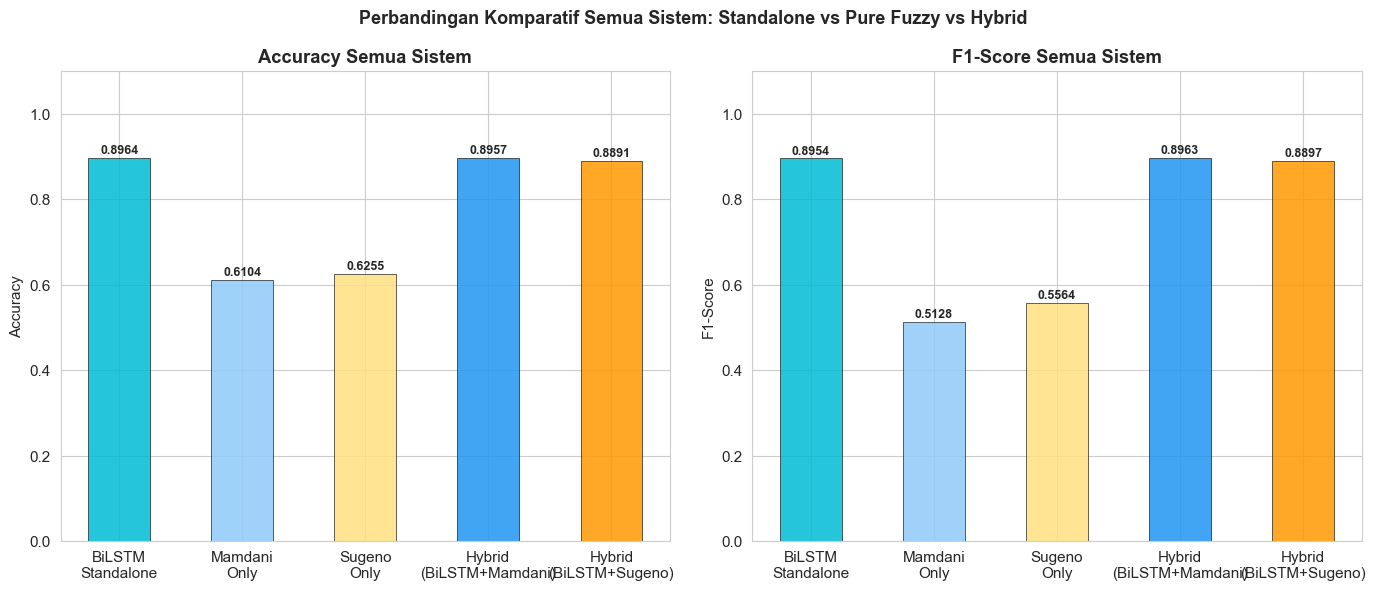

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

systems = [
    'BiLSTM\nStandalone',
    'Mamdani\nOnly',
    'Sugeno\nOnly',
    'Hybrid\n(BiLSTM+Mamdani)',
    'Hybrid\n(BiLSTM+Sugeno)'
]
accuracies = [
    accuracy_score(y_test, y_pred_test),
    acc_without_dl,
    acc_s_without_dl,
    acc_with_dl,
    acc_s_with_dl
]
f1scores = [
    f1_score(y_test, y_pred_test, average='weighted'),
    f1_without,
    f1_s_without,
    f1_with,
    f1_s_with
]

colors_sys = ['#00BCD4', '#90CAF9', '#FFE082', '#2196F3', '#FF9800']

ax = axes[0]
bars = ax.bar(systems, accuracies, color=colors_sys, alpha=0.85, width=0.5, edgecolor='black', linewidth=0.5)
ax.set_title('Accuracy Semua Sistem', fontweight='bold')
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
for b, v in zip(bars, accuracies):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=9)

ax = axes[1]
bars = ax.bar(systems, f1scores, color=colors_sys, alpha=0.85, width=0.5, edgecolor='black', linewidth=0.5)
ax.set_title('F1-Score Semua Sistem', fontweight='bold')
ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
for b, v in zip(bars, f1scores):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Perbandingan Komparatif Semua Sistem: Standalone vs Pure Fuzzy vs Hybrid',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/all_systems.png', bbox_inches='tight')
plt.show()
